# Activity 0.2. Probability
(last modified 8 March 2023)

### Learning Outcomes

In this activity we learn how to:

- use numpy `ufunc` to implement probability density functions
- use the density function of the exponential distribution to find probabilities
- compute the expected value of an exponentially distributed random variable using integration by parts
- apply maximum likelihood parameter estimation to infer the parameter of an exponential random variable from data

Prerequisites

- Calculus (integration and differentiation)
- Basic probability concepts (as recapped in Lecture 2)


### The Density Function of the Exponential Distribution

Lecture 2 uses an example of modelling the time until one receives ones first email during a work day via an **exponential distribution**. Exponentially distributed random variables are continuous random variables $X$ with domain $D_X=[0, \infty)$ and a probabiloty density function (pdf) of the form

\begin{equation*}
p(x) = w\exp(-wx)
\end{equation*}

where the parameter $w$ is known as the **rate parameter**. Let us implement this density function to visualise it and to understand the influence of the rate parameter.

#### Task A: Implement the exponential pdf

**Finish the implementation below**

In [40]:
import numpy as np
from numpy import exp

def expon_pdf(y, w=1):
    return w*exp(-w*y)

expon_pdf(2)

0.1353352832366127

The `numpy` function `exp` is a universal function (or [ufunc](https://numpy.org/doc/stable/user/basics.ufuncs.html#ufuncs-basics)), which means that it can, e.g., be called with array arguments and it will be applied element-wise. With our implementation we should have inherited this behaviour for our implementation of the exponential pdf, which is very useful for plotting.

In [42]:
y = np.linspace(0, 1, 10)
expon_pdf(y, 2)

array([2.        , 1.60147481, 1.28236078, 1.02683424, 0.82222458,
       0.65838598, 0.52719428, 0.42214418, 0.33802663, 0.27067057])

Let us use now plot the pdf for different values of the rate parameter. Before you run this the next cell, answer the following question.

#### Task B: What is the influence of the rate parameter on the pdf?

*The higher the rate the faster the probability mass drops to 0, i.e., the more mass is shifted to the left.*

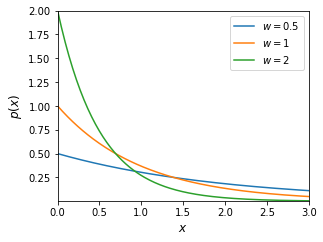

In [45]:
from matplotlib import pyplot as plt

y = np.linspace(0, 3, 200)
ws = [0.5, 1, 2]

font = {'size': 'large'}
plt.figure(figsize=(4.5, 3.5))
for w in ws:
    plt.plot(y, expon_pdf(y, w), label=f'$w={w}$')
plt.ylabel('$p(x)$', fontdict=font)
plt.xlabel('$x$', fontdict=font)
plt.margins(x=0, y=0)
plt.legend()
plt.show()


### Computing Probabilities from Densities

Probability densities encode probabilities of an event like $X \in [a, b]$ as the area under the curve of the density function between $a$ and $b$, i.e., via integration:
$$
\Pr(X \in [a, b]) = \int_{a}^b p(x) dx .
$$
For example if I know that the arrival time of my first email is exponentially distributed with rate parameter $w=1.5$ and I want to know what is the probability of receiving my first email within my second hour of work, I can compute
$$
\Pr(X \in [1, 2]) = \int_{1}^2 p(x) dx = \int_{1}^2 1.5\exp(-1.5x) dx \enspace.
$$

Let us visualise the area under the curve that corresponds to that probability.

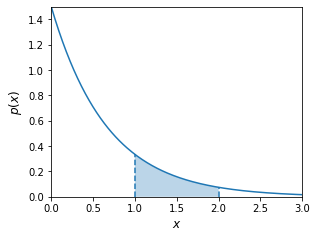

In [46]:
w = 1.5
plt.figure(figsize=(4.5, 3.5))
plt.plot(y, expon_pdf(y, w), label='$w=0.5$')
plt.ylabel('$p(x)$', fontdict=font)
plt.xlabel('$x$', fontdict=font)
plt.margins(x=0, y=0)
plt.fill_between(np.linspace(1, 2, 50), expon_pdf(np.linspace(1, 2, 50), w), alpha=0.3)
plt.vlines(1, 0, expon_pdf(1, w), linestyles='--')
plt.vlines(2, 0, expon_pdf(2, w), linestyles='--')
plt.show()

By the fundamental theorem of calculus we can compute definite integrals of a function $f$ via
$$
\int_a^b f(x)dx = F(b) - F(a) = [F(x)]_a^b
$$
where $F$ is an anti-deriviative of $f$, i.e., any function $F$ that satisfies
$$
\frac{d}{dx} F(x) = f(x) \enspace .
$$

Thus, we can compute probabilities for an exponentially distributed random variable, if we can find an anti-derivative of the density, i.e., a function $P(x)$ with the property that its derivative is given as 
$$
    \frac{d}{dx}P(x)=p(x)=w\exp(-wx) \enspace .
$$

#### Task C: Find an anti-derivative of the exponential pdf

Hint: Remember the chain rule for derivatives and that the derivative of the exponential function is the exponential function itself, i.e., $d\exp(x)/dx=\exp(x)$.

\begin{equation*}
P(x) = -\exp(-wx)
\end{equation*}

In [48]:
exp(-w*1)-exp(-w*2)

0.17334309178056587

### Expected Value

The expected value (or mean value) of a continuous random variable $X$ with domain $D_X$ is defined as
$$
\mathbb{E}[X] = \int_{D_x} x\, p(x) dx \enspace .
$$

This means for our case of an exponentially distributed $X$ with rate parameter $w$ that
$$
\mathbb{E}[X] = \int_0^\infty x w \exp(-wx) dx \enspace .
$$

Let us see what is the value of the expected value in terms of the rate parameter. Solving this integral will be a bit more challenging and we have to use an advanced integration technique: integration by parts.

Integration by parts is an integration rule that allows us to simplify integrals over products of functions (like in our case the product of $x$ and $w\exp(-wx)$). The rule is
$$
\int_a^b f(x)g'(x)dx = [f(x)g(x)]_a^b - \int_a^b f'(x)g(x) dx
$$
with where $f'(x)$ and $g'(x)$ denote the derivatives of functions $f$ and $g$, respectively. 

When you see this for the first time it might not seem very useful. However, note that this formula allows us to simplify our task substantially if we choose
\begin{align*}
f(x) &= x \\
g'(x) &= w\exp(-wx)
\end{align*}
because with this choice $f'(x)$ simply becomes the constant $1$ and, by observing that $g$ is our exponential density $p$, we already know the anti-derivative $g(x)$. Let us use this to find the expected value.

#### Task D: Find the expected value in terms of the rate parameter

**Finish the derivation below and then compute the expected value for $w=1.5$ in the subsequent visualisation code.**

Hint: The only thing that remains to be done is to find an anti-derivative of $\exp(-wx)$ to solve the remaining integral. Recall from above, how we can find anti-derivatives of exponential functions using the chain rule.

\begin{align*}
\int_{0}^\infty x w\exp(-wx)dx &= [-x\exp(-wx)]_0^\infty - \int_0^\infty \exp(-wx)\\
&=0 - 0 - \left[-\frac{1}{w}\exp(-wx)\right]_0^\infty\\
&=\frac{1}{w}
\end{align*}

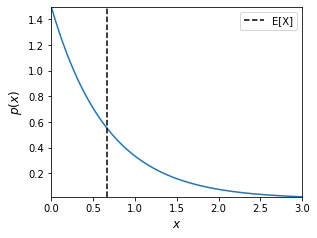

In [53]:
w = 1.5
mean_value = 1/w

plt.figure(figsize=(4.5, 3.5))
plt.plot(y, expon_pdf(y, w))
plt.axvline(mean_value, color='black', linestyle='--', label = 'E[X]')
plt.ylabel('$p(x)$', fontdict=font)
plt.xlabel('$x$', fontdict=font)
plt.margins(x=0, y=0)
plt.legend()
plt.show()

### Maximum Likelihood Parameter Estimation

Finally, let us estimate the rate parameter of an exponential distribution given training data. To generate the data, we will use the implementation of the exponential distribution in the `scipy.stats` module called `expon`. In particular, we use the method `rvs` to generate a number $n=20$ of independent realisations of the random variable. 

Note that the scipy implementation of the exponential distribution uses a different parameterisation where we have to specifiy instead of the rate parameter its inverse, i.e., the mean.

In [83]:
from scipy.stats import expon

w_true = 1.5
n = 20
x = expon.rvs(0, 1/w_true, size=n, random_state=0)
x

array([0.53058301, 0.83728718, 0.6154821 , 0.52480077, 0.36736566,
       0.6921062 , 0.38367947, 1.48234961, 2.20994145, 0.3224014 ,
       1.04593076, 0.50178274, 0.5596219 , 1.73216944, 0.04912357,
       0.06077402, 0.01361706, 1.19165845, 1.00385615, 1.36020952])

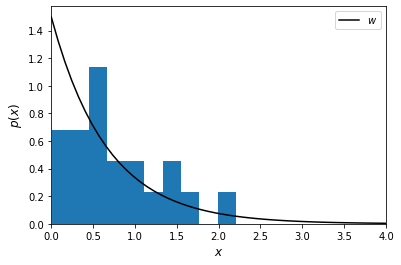

In [89]:
plt.hist(x, density=True, bins=10)
xx = np.linspace(0, 4)
plt.plot(xx, expon_pdf(xx, w_true), color='black', label='$w$')
plt.margins(x=0)
plt.legend()
plt.ylabel('$p(x)$', fontdict=font)
plt.xlabel('$x$', fontdict=font)
plt.show()

The principle of maximum likelihood estimation (MLE) is to maximise the likelihood function, i.e., the probability of the observed data (assuming our model) as a function of the parameter:
$$
p(x_1, \dots, x_N | w) = \prod_{n=1}^N p(x_n | w)
$$
where the equality holds because we assume that the individual data points have been generated independently of each other. 

To optimise the function, we can as usually use the derivative criterion. However, this is going to be hard to apply with the product. Hence, one typically resorts to maximising the log-transformed likelhihood function instead. 

In short, the recipe for finding the maximum likelihood paramaters is:

1. Write down the log likelihood function
2. Form the derivative in the parameters
3. Set to 0 and solve

#### Task E: Derivate and implement MLE for the exponential distribution

**Finish the derivation below. Afterwards implement the maximum likelihood estimator in the following code cell.** 

Step 1
\begin{align*}
\log \prod_{n=1}^N p(x_n | w) &= \sum_{n=1}^N \log p(x_n | w)\\
&= \sum_{n=1}^N \log w\exp(-wx_n)\\
&= N\log w - w\sum_{n=1}^N x_n
\end{align*}

Step 2
\begin{align*}
\frac{d}{dw} \log \prod_{n=1}^N p(x_n | w) &= \frac{d}{dw} \left (N\log w - w\sum_{n=1}^N x_n\right )\\
&=\frac{N}{w} - \sum_{n=1}^N x_n
\end{align*}

Step 3
$$
\frac{N}{w} - \sum_{n=1}^N x_n = 0 \Rightarrow w = N/\sum_{n=1}^N x_n
$$


In [90]:
def expon_mle(x):
    return len(x) / sum(x)

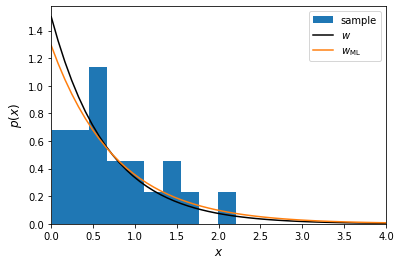

In [91]:
w_ml = expon_mle(x)

plt.hist(x, density=True, bins=10, label='sample')
xx = np.linspace(0, 4)
plt.plot(xx, expon_pdf(xx, w_true), color='black', label='$w$')
plt.plot(xx, expon_pdf(xx, w_ml), label='$w_\mathrm{ML}$')
plt.margins(x=0)
plt.legend()
plt.ylabel('$p(x)$', fontdict=font)
plt.xlabel('$x$', fontdict=font)
plt.show()